#Q1
# 엘센트로 지반가속도에 대하여 주기가 감쇠비가 5%, 0.1초, 0.5초, 1.0초, 2.0초인 단자유도 구조물에 대하여 시간대 변위 그림을 그리시오.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# 시스템 입력
Tn = np.array([0.1, 0.5, 1.0, 2.0])
dratio = np.array([0.05, 0.1])

In [3]:
# 시간 정의
Td = 50 # 초
dt = 0.01 # 초
T = np.arange(0, Td, dt)
nstep = len(T)

In [4]:
# 하중 정의
Eq = np.loadtxt('elcentro.txt')
xg = Eq[:,1]*9.81
print(np.max(xg))

3.4211137959


In [5]:
Eq[0,0]-Eq[1,0]

np.float64(-0.02)

In [6]:
len(Eq)

2688

In [7]:
# raw 데이터는 2688개인데 5000으로 선형보간해서 추가하기

import pandas as pd
from scipy.interpolate import interp1d

T1 = Eq[:,0]

# 선형 보간 수행
interp_func = interp1d(T1, xg, kind='linear', fill_value="extrapolate")
nxg = interp_func(T)

# 결측치 선형 보간으로 채우기
nxg = pd.Series(nxg).interpolate(method='linear').to_numpy()

# 결과를 U에 저장
U = nxg

In [8]:
len(U)

5000

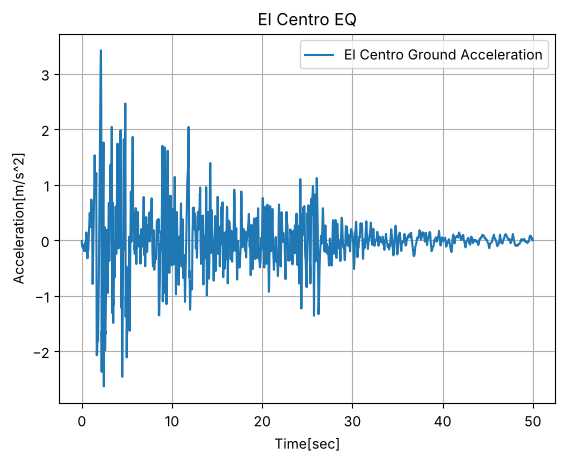

In [9]:
plt.plot(T, U, label = 'El Centro Ground Acceleration')
plt.legend()
plt.xlabel('Time[sec]')
plt.ylabel('Acceleration[m/s^2]')
plt.title('El Centro EQ')
plt.grid()

plt.show()

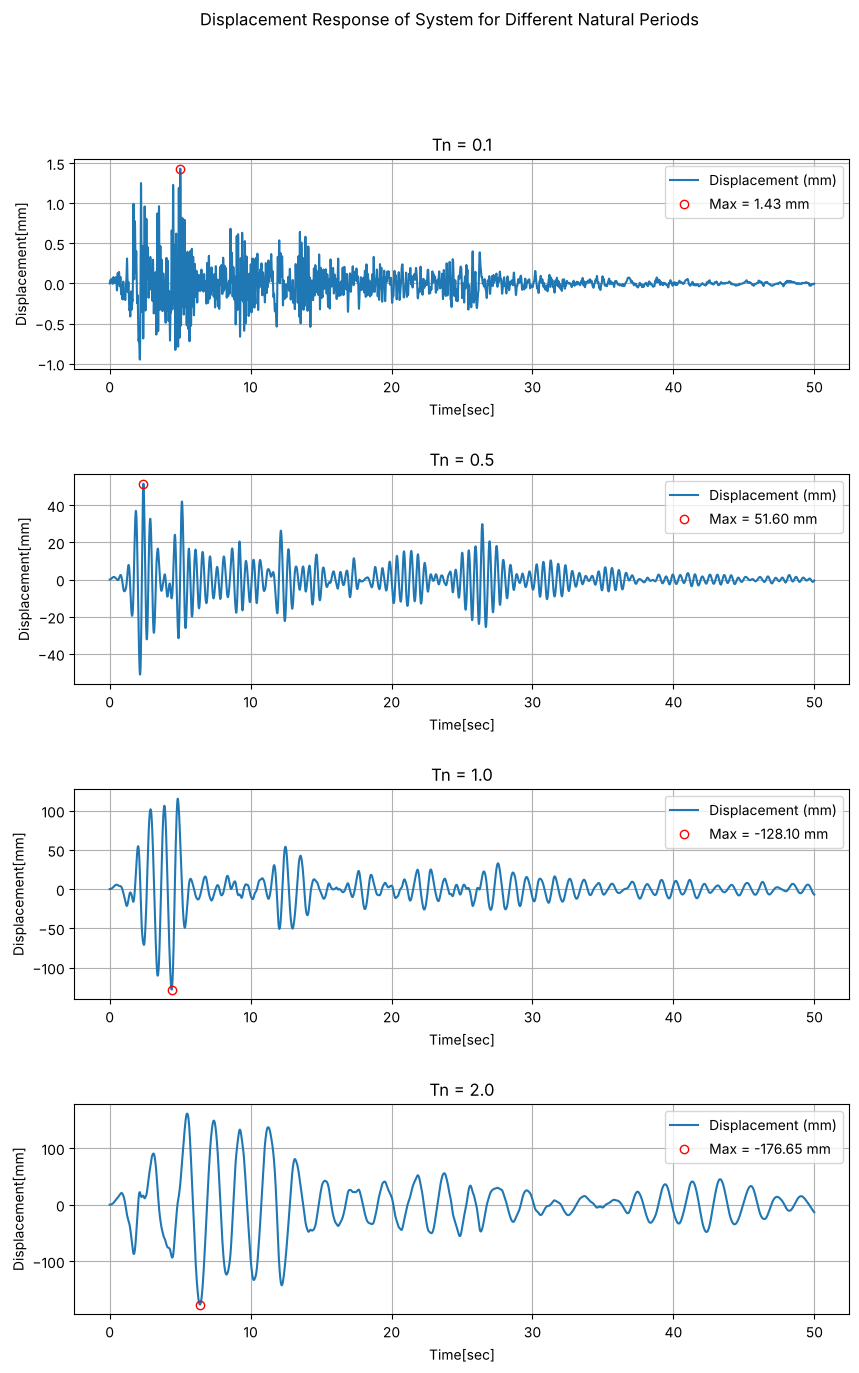

In [10]:
# 상태방정식으로 응답계산
from scipy.signal import cont2discrete, dlti, dstep

plt.figure(figsize=(10, 15))

max_disp = np.zeros((len(Tn),1))

for ii in range(len(Tn)):
  wn = 2*np.pi/Tn[ii]
  Z = np.zeros((2,nstep))
  A = np.array([[0,1],[-wn**2, -2*dratio[0]*wn]])
  B = np.array([[0],[-1]]);

  system = (A, B, None, None)
  sys_discrete = cont2discrete(system, dt)
  Ad, Bd = sys_discrete[0],sys_discrete[1]


  for jj in range(nstep-1):
    Z[:,jj+1] = Ad @ Z[:,jj] + Bd.flatten()* U[jj]


  max_index = np.argmax(np.abs(Z[0, :]))  # 절대값 최대값의 인덱스
  max_value = Z[0, max_index] *1000   # m -> mm 단위 변환


  plt.subplot(4,1,ii+1)
  plt.plot(T, Z[0, :] * 1000, label='Displacement (mm)')
  plt.plot(T[max_index], max_value, 'o',markerfacecolor='none', color='red', label=f'Max = {max_value:.2f} mm')  # 최대값 위치에 o 마커 추가
  plt.title(f'Tn = {Tn[ii]}')
  plt.grid()
  plt.xlabel('Time[sec]')
  plt.ylabel('Displacement[mm]')
  plt.legend()

  max_disp[ii] = np.abs(max_value)

plt.subplots_adjust(hspace=0.5)  # 그래프 간격을 조절 (hspace 값 조정)
plt.suptitle('Displacement Response of System for Different Natural Periods', fontsize=12)
plt.show()

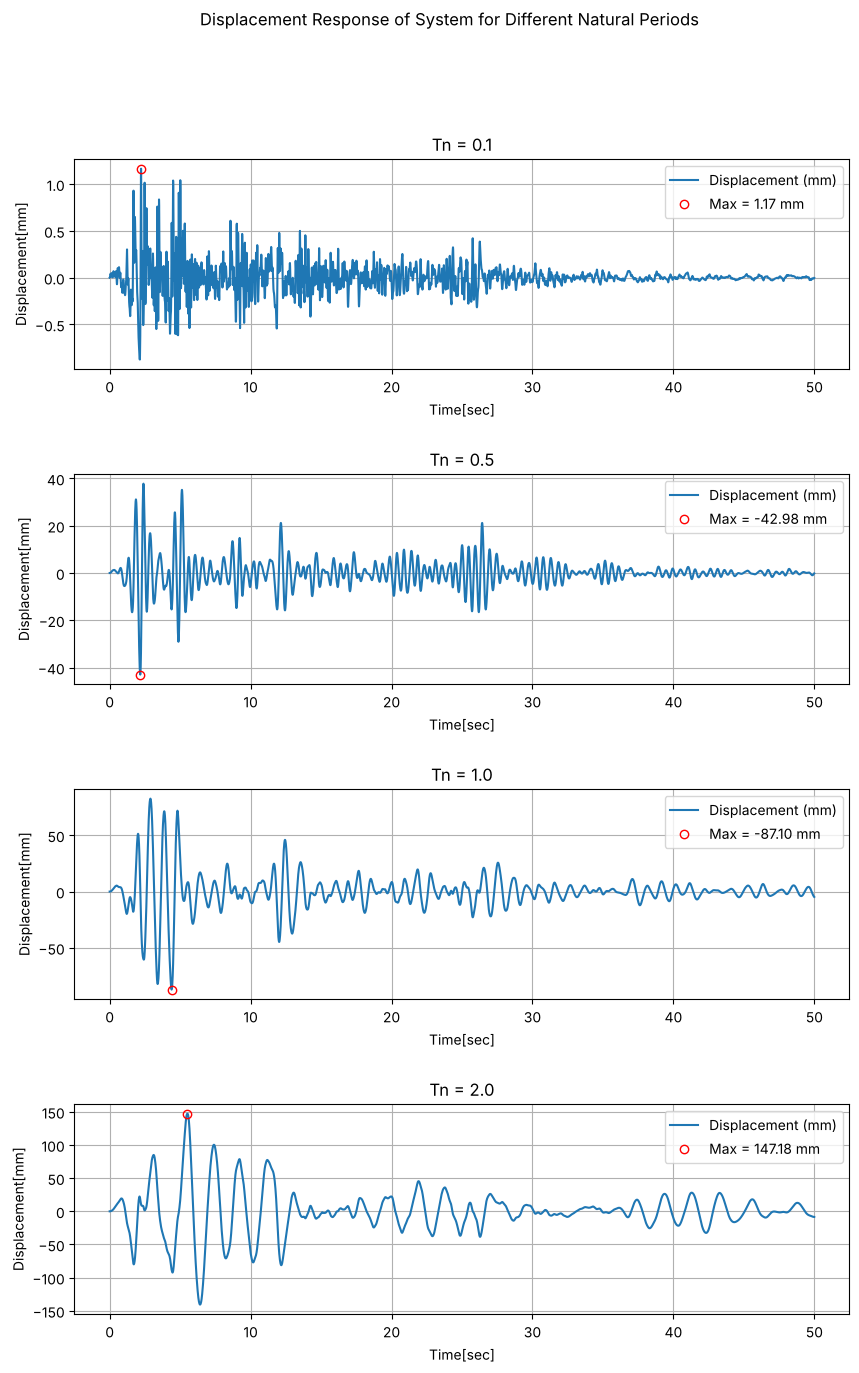

In [11]:
# 상태방정식으로 응답계산
from scipy.signal import cont2discrete, dlti, dstep

plt.figure(figsize=(10, 15))

max_disp = np.zeros((len(Tn),1))

for ii in range(len(Tn)):
  wn = 2*np.pi/Tn[ii]
  Z = np.zeros((2,nstep))
  A = np.array([[0,1],[-wn**2, -2*dratio[1]*wn]])
  B = np.array([[0],[-1]]);

  system = (A, B, None, None)
  sys_discrete = cont2discrete(system, dt)
  Ad, Bd = sys_discrete[0],sys_discrete[1]


  for jj in range(nstep-1):
    Z[:,jj+1] = Ad @ Z[:,jj] + Bd.flatten()* U[jj]


  max_index = np.argmax(np.abs(Z[0, :]))  # 절대값 최대값의 인덱스
  max_value = Z[0, max_index] *1000   # m -> mm 단위 변환


  plt.subplot(4,1,ii+1)
  plt.plot(T, Z[0, :] * 1000, label='Displacement (mm)')
  plt.plot(T[max_index], max_value, 'o',markerfacecolor='none', color='red', label=f'Max = {max_value:.2f} mm')  # 최대값 위치에 o 마커 추가
  plt.title(f'Tn = {Tn[ii]}')
  plt.grid()
  plt.xlabel('Time[sec]')
  plt.ylabel('Displacement[mm]')
  plt.legend()

  max_disp[ii] = np.abs(max_value)

plt.subplots_adjust(hspace=0.5)  # 그래프 간격을 조절 (hspace 값 조정)
plt.suptitle('Displacement Response of System for Different Natural Periods', fontsize=12)
plt.show()

# Q2
# 2. 엘센트로 지반가속도에 대하여 구조물의 주기가 0.01초에서 0.01초 간격으로 5초까지 변화할 때 5%감쇠비를 가지는 구조물의 변위 및 유사가속도응답스펙트럼을 구해서 주기와 변위응답스텍트럼, 주기와 유사가속도응답스펙트럼의 그림을 그리시오

In [12]:
Tn = np.arange(0.01, 5, 0.01)
dratio = np.array([0.05, 0.1])


In [13]:
Td = 50
dt = 0.01
T = np.arange(0, Td, dt)
nstep = len(T)

In [14]:
import pandas as pd
from scipy.interpolate import interp1d

T1 = Eq[:,0]

# 선형 보간 수행
interp_func = interp1d(T1, xg, kind='linear', fill_value="extrapolate")
nxg = interp_func(T)

# 결측치 선형 보간으로 채우기
nxg = pd.Series(nxg).interpolate(method='linear').to_numpy()

# 결과를 U에 저장
U = nxg

In [15]:
xmax_1 = np.zeros(len(Tn))
amax_1 = np.zeros(len(Tn))

xmax_2 = np.zeros(len(Tn))
amax_2 = np.zeros(len(Tn))


In [16]:
# 응답 계산
from scipy.signal import cont2discrete, dlti, dstep

for ii in range(len(Tn)):
  wn = 2*np.pi/Tn[ii]
  Z = np.zeros((2,nstep))
  A = np.array([[0,1],[-wn**2, -2*dratio[0]*wn]])
  B = np.array([[0],[-1]]);

  system = (A, B, None, None)
  sys_discrete = cont2discrete(system, dt)
  Ad, Bd = sys_discrete[0], sys_discrete[1]

  for jj in range(nstep-1):
    Z[:,jj+1] = Ad @ Z[:,jj] + Bd.flatten()* U[jj]

  xmax_1[ii] = np.max(np.abs(Z[0,:]))
  amax_1[ii] = xmax_1[ii]*wn**2



In [17]:
from scipy.signal import cont2discrete, dlti, dstep

for ii in range(len(Tn)):
  wn = 2*np.pi/Tn[ii]
  Z = np.zeros((2,nstep))
  A = np.array([[0,1],[-wn**2, -2*dratio[1]*wn]])
  B = np.array([[0],[-1]]);

  system = (A, B, None, None)
  sys_discrete = cont2discrete(system, dt)
  Ad, Bd = sys_discrete[0], sys_discrete[1]

  for jj in range(nstep-1):
    Z[:,jj+1] = Ad @ Z[:,jj] + Bd.flatten()* U[jj]

  xmax_2[ii] = np.max(np.abs(Z[0,:]))
  amax_2[ii] = xmax_2[ii]*wn**2


Font 'default' does not have a glyph for '\uacc4' [U+acc4], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\uce21' [U+ce21], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\uac00' [U+ac00], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\uc18d' [U+c18d], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\ub3c4' [U+b3c4], substituting with a dummy symbol.


...

Font 'default' does not have a glyph for '\uac00' [U+ac00], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\uc18d' [U+c18d], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\ub3c4' [U+b3c4], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\uc544' [U+c544], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\ub2d8' [U+b2d8], substituting with a dummy symbol.


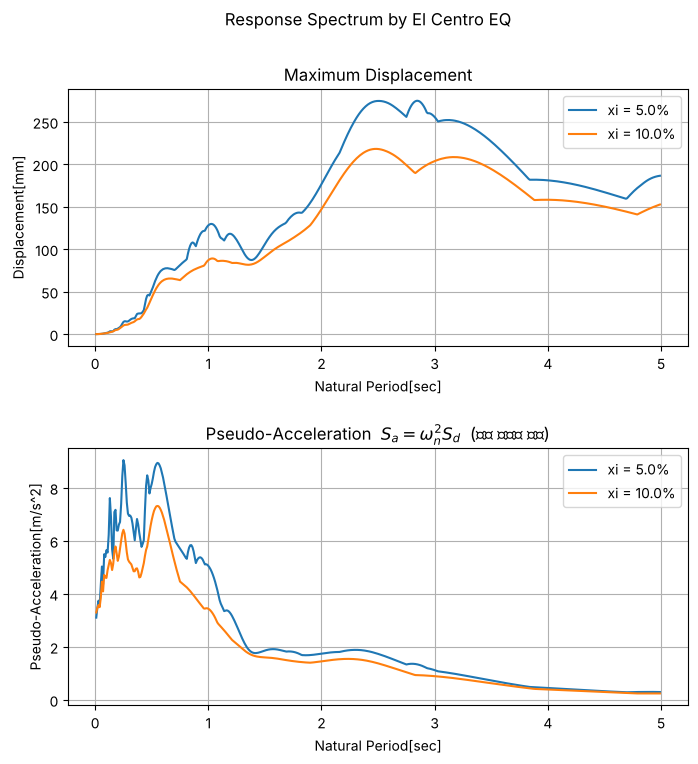

In [18]:
plt.figure(figsize=(8, 8))
plt.subplot(2,1,1)
plt.plot(Tn, xmax_1*1000, label = f'xi = {dratio[0]*100}%')
plt.plot(Tn, xmax_2*1000, label = f'xi = {dratio[1]*100}%')
plt.legend()
plt.title('Maximum Displacement')
plt.xlabel('Natural Period[sec]')
plt.ylabel('Displacement[mm]')
plt.grid()

plt.subplot(2,1,2)
plt.plot(Tn, amax_1, label = f'xi = {dratio[0]*100}%')
plt.plot(Tn, amax_2, label = f'xi = {dratio[1]*100}%')
plt.legend()
plt.xlabel('Natural Period[sec]')
plt.ylabel('Pseudo-Acceleration[m/s^2]')
plt.title('Pseudo-Acceleration  $S_a = \\omega_n^2 S_d$  (계측 가속도 아님)')
plt.grid()

plt.suptitle('Response Spectrum by El Centro EQ', fontsize=12)
plt.subplots_adjust(hspace=0.4)
plt.show()

> **[수정 2026-10]** 아래 가속도 그래프는 최대변위에 $\omega_n^2$를 곱한 **유사가속도**(pseudo-acceleration)입니다. 구조물이 실제로 겪은 절대가속도의 최댓값이 아닙니다. 감쇠 5%에서는 두 값이 거의 같지만, 감쇠가 크면 차이가 벌어집니다.

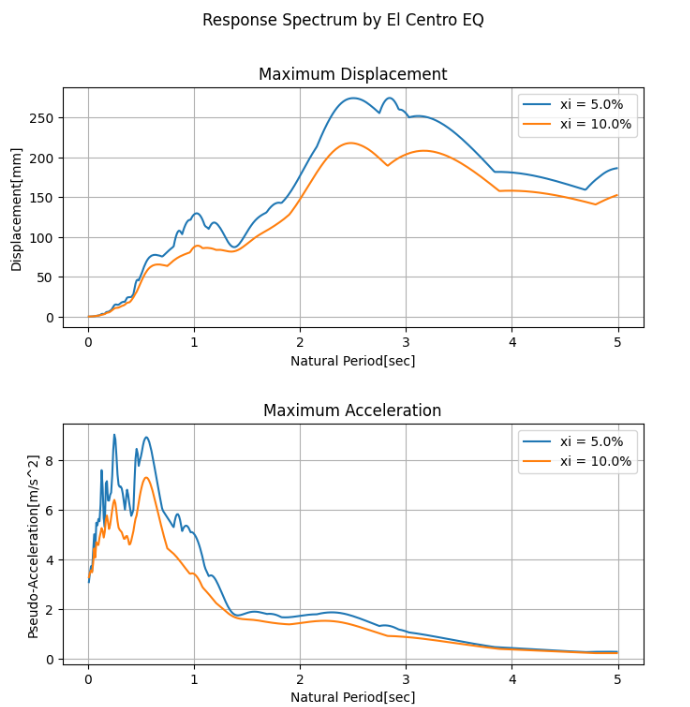

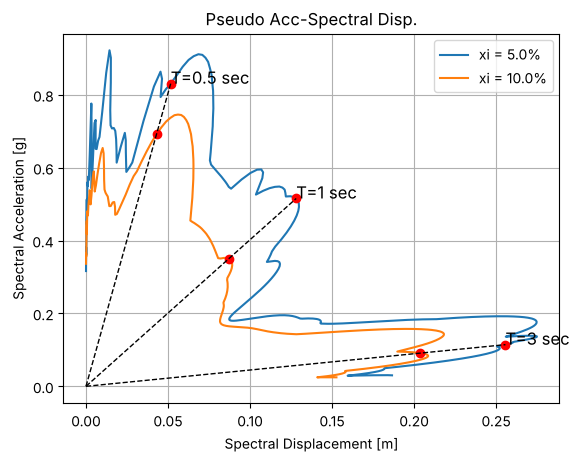

In [19]:
plt.plot(xmax_1, amax_1/9.81, label = f'xi = {dratio[0]*100}%')
plt.plot(xmax_2, amax_2/9.81, label = f'xi = {dratio[1]*100}%')
plt.legend()
plt.title('Pseudo Acc-Spectral Disp.')
plt.xlabel('Spectral Displacement [m]')
plt.ylabel('Spectral Acceleration [g]')
plt.grid()

# Mark periods corresponding to 0.5, 1, and 3 seconds
for period in [0.5, 1, 3]:
  if period in Tn:
    index = np.where(Tn == period)[0][0]
    plt.plot(xmax_1[index], amax_1[index]/9.81, 'ro')
    plt.text(xmax_1[index], amax_1[index]/9.81, f'T={period} sec', fontsize=12)
    plt.plot(xmax_2[index], amax_2[index]/9.81, 'ro')
    #plt.text(xmax_2[index], amax_2[index]/9.81, f'T={period} sec', fontsize=12)

# Draw dashed lines from (0,0) to the marked points with text
for period in [0.5, 1, 3]:
  if period in Tn:
    index = np.where(Tn == period)[0][0]
    plt.plot([0, xmax_1[index]], [0, amax_1[index]/9.81], 'k--', linewidth=1)

plt.show()

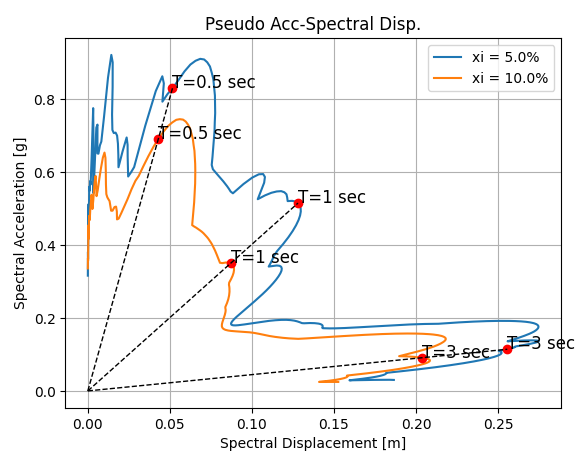

In [20]:
# 데이터 저장
output_data = np.column_stack((Tn, xmax_1, amax_1, xmax_2, amax_2))
np.savetxt('output.txt', output_data, fmt='%.6f', delimiter=' ')


# 3. 주기와 지반가속도는 2번의 경우이고 감쇠비가 0%, 2%, 5%, 10%인 경우에 가속도 응답스펙트럼을 비교하시오.

In [21]:
Tn = np.arange(0.01, 5, 0.01)
dratio = np.array([0, 0.02, 0.05, 0.1])

In [22]:
Td = 50
dt = 0.01
T = np.arange(0, Td, dt)
nstep = len(T)

In [23]:
import pandas as pd
from scipy.interpolate import interp1d

T1 = Eq[:,0]

# 선형 보간 수행
interp_func = interp1d(T1, xg, kind='linear', fill_value="extrapolate")
nxg = interp_func(T)

# 결측치 선형 보간으로 채우기
nxg = pd.Series(nxg).interpolate(method='linear').to_numpy()

# 결과를 U에 저장
U = nxg

In [24]:
xmax = np.zeros(len(Tn))
amax = np.zeros(len(Tn))


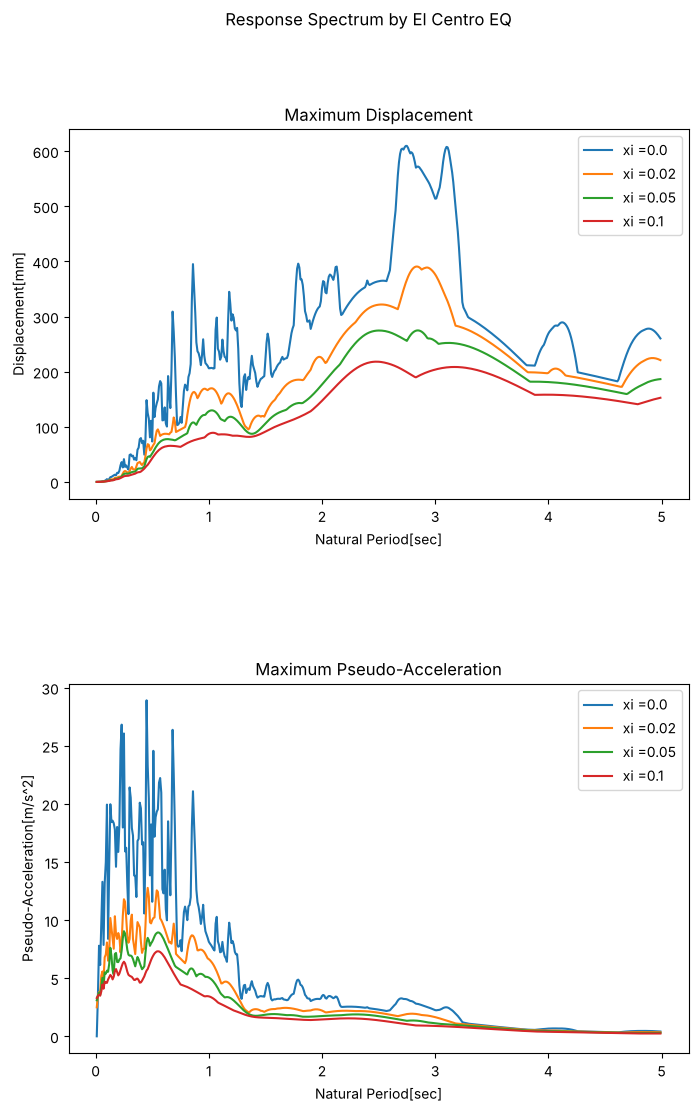

In [25]:
# 응답 계산

from scipy.signal import cont2discrete, dlti, dstep

plt.figure(figsize=(8, 12))

for ii in range(len(dratio)):
  for jj in range(len(Tn)):
    wn = 2*np.pi/Tn[jj]
    Z = np.zeros((2,nstep))
    A = np.array([[0,1],[-wn**2, -2*dratio[ii]*wn]])
    B = np.array([[0],[-1]]);

    system = (A, B, None, None)
    sys_discrete = cont2discrete(system, dt)
    Ad, Bd = sys_discrete[0], sys_discrete[1]

    for kk in range(nstep-1):
      Z[:,kk+1] = Ad @ Z[:,kk] + Bd.flatten()* U[kk]

    xmax[jj] = np.max(np.abs(Z[0,:]))
    amax[jj] = xmax[jj]*wn**2

  plt.subplot(2,1,1)
  plt.plot(Tn, xmax*1000, label = f'xi ={dratio[ii]}')
  plt.legend()
  plt.title('Maximum Displacement')
  plt.xlabel('Natural Period[sec]')
  plt.ylabel('Displacement[mm]')
  plt.grid()

  plt.subplot(2,1,2)
  plt.plot(Tn, amax, label = f'xi ={dratio[ii]}')
  plt.legend()
  plt.xlabel('Natural Period[sec]')
  plt.ylabel('Pseudo-Acceleration[m/s^2]')
  plt.title('Maximum Pseudo-Acceleration')
  plt.grid()


plt.subplots_adjust(hspace=0.5)
plt.suptitle('Response Spectrum by El Centro EQ', fontsize=12)
plt.show()

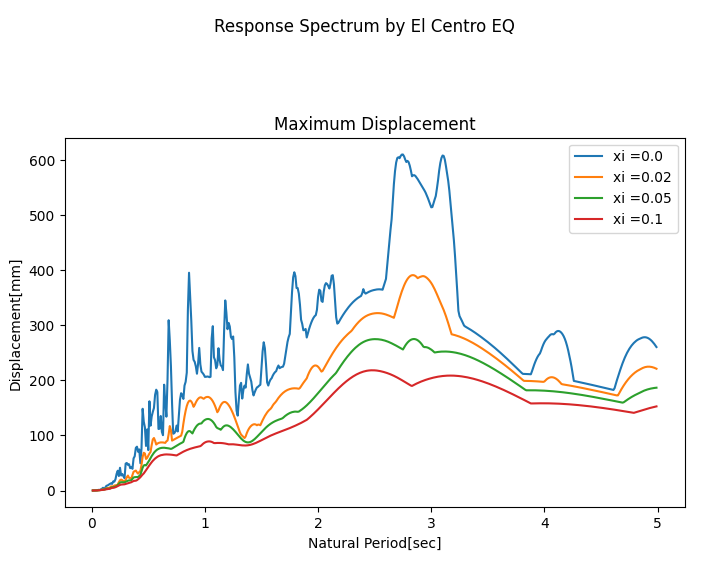

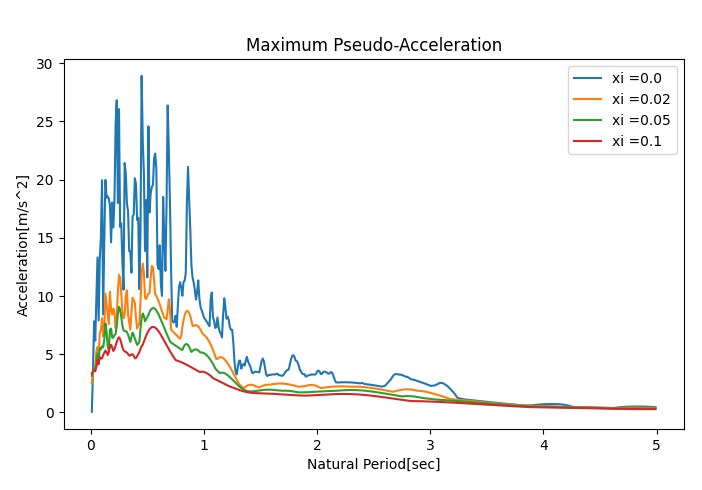